In [6]:
from data_cleaning import prep_raw_data
df = prep_raw_data(path='../raw/apartments_pl_2024_06.csv',path_shp='../raw/dzielnice_Warszawy/dzielnice_Warszawy.shp')

df

,squareMeters,rooms,floor,buildYear,centreDistance,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,district_number,district
13604,35.80,2.0,1.0,1981.0,7.23,0,1,1,1,0,1,548900,17,Bemowo
13605,52.00,3.0,5.0,1975.0,6.34,0,1,1,1,0,1,690000,17,Bemowo
13610,127.47,4.0,2.0,1998.0,5.89,1,1,0,0,0,0,2700000,17,Bemowo
13625,65.60,3.0,4.0,2009.0,9.59,0,1,0,1,1,0,1107000,8,Ursynów
13626,36.00,2.0,7.0,1965.0,4.38,1,0,0,1,0,1,684000,2,Mokotów
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20520,72.00,3.0,8.0,2014.0,6.17,1,1,1,1,1,0,1150000,1,Praga-Południe
20528,86.50,4.0,6.0,1998.0,3.85,1,1,0,1,0,0,1750700,3,Wola
20534,136.00,4.0,6.0,2002.0,0.63,0,1,1,1,0,0,2170000,9,Śródmieście
20536,72.00,3.0,9.0,2019.0,3.16,1,1,0,1,0,0,1850000,3,Wola


In [7]:
df.describe(

)

,squareMeters,rooms,floor,buildYear,centreDistance,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,district_number
count,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1.059000e+03,1059.000000
mean,58.150085,2.649669,3.915958,1995.636449,6.216213,0.584514,0.554297,0.745987,0.797923,0.083097,0.437205,1.056613e+06,7.265345
std,20.426990,0.866858,3.069381,21.135825,2.927516,0.493039,0.497278,0.435511,0.401739,0.276160,0.496275,4.555781e+05,5.597093
min,25.500000,1.000000,1.000000,1936.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.990000e+05,0.000000
25%,44.000000,2.000000,2.000000,1976.000000,4.115000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,7.500000e+05,2.000000
50%,54.900000,3.000000,3.000000,2002.000000,6.170000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,9.290000e+05,7.000000
75%,68.375000,3.000000,5.000000,2015.000000,8.190000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.200000e+06,12.000000
max,149.000000,6.000000,29.000000,2024.000000,15.900000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.990000e+06,17.000000


In [ ]:
#squareMeters: we can conclude that mean number of squareMeters are 58, but middle 50% of values are between 44 and 5
#rooms: we can conclude that mean number of rooms are 3(mean is 2.64 , but we will round it to whole number), middle 50% of estates has 2 or 3 rooms
#floor: mean is 4, but 50% of middle observations are between 2 and 5. but max floor is 29, so it explains us why the mean is so big
#price: price range is between 499000 PLN and 2990000 PLN, but middle 50% of estates cost between 750000PLN and 1200000PLN


{'whiskers': [<matplotlib.lines.Line2D at 0x283587906e0>,
 'caps': [<matplotlib.lines.Line2D at 0x28358790980>,
 'boxes': [<matplotlib.lines.Line2D at 0x28358790590>],
 'medians': [<matplotlib.lines.Line2D at 0x28358790c20>],
 'fliers': [<matplotlib.lines.Line2D at 0x28358790d70>],
 'means': []}

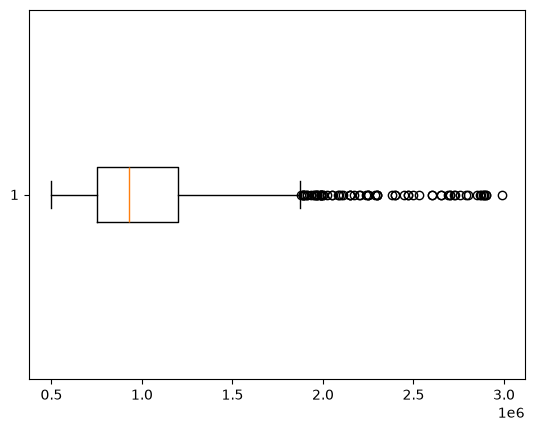

In [11]:
import matplotlib.pyplot as plt

#we are making box plot of price
plt.boxplot(df["price"],orientation="horizontal")
#Boxplot shows that we have many outliers which are out of basic range

(array([ 59.,   0., 428.,   0., 432.,   0., 113.,   0.,  19.,   8.]),
 array([1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. ]),
 <BarContainer object of 10 artists>)

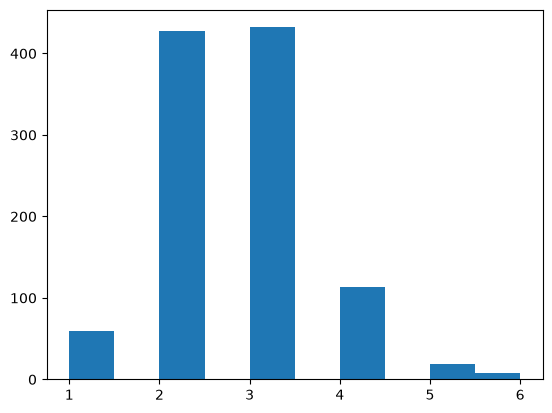

In [12]:
#histogram of rooms
plt.hist(df["rooms"])
#it confirms what describe() said, most of estates has 2 or 3 rooms

In [17]:
#correlation
df_corr=df.drop(columns="district")
df_corr.corr()["price"].sort_values(ascending=False)
#correlation says that biggest dependencies on price have squareMeters, rooms and buildYear. Biggest negative correlation has hasStorageRoom

price              1.000000
squareMeters       0.820555
rooms              0.575015
buildYear          0.364185
hasParkingSpace    0.323108
condition          0.309574
hasElevator        0.186295
hasSecurity        0.098953
floor              0.042890
hasBalcony         0.032280
centreDistance    -0.075926
district_number   -0.188472
hasStorageRoom    -0.262783
Name: price, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x28359f10590>,
 'caps': [<matplotlib.lines.Line2D at 0x28359f10830>,
 'boxes': [<matplotlib.lines.Line2D at 0x28359f10440>],
 'medians': [<matplotlib.lines.Line2D at 0x28359f10ad0>],
 'fliers': [<matplotlib.lines.Line2D at 0x28359f10c20>],
 'means': []}

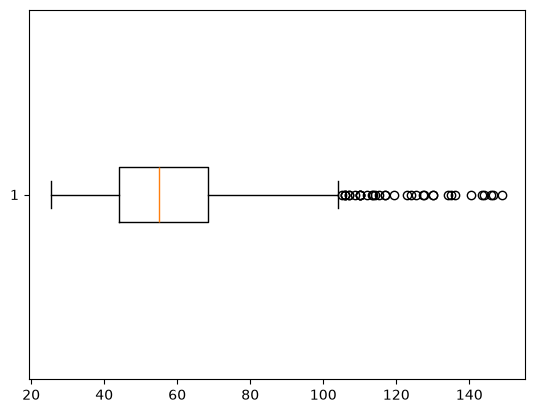

In [19]:
plt.boxplot(df_corr["squareMeters"],orientation="horizontal")
#Boxplot shows that we have some outliers which are out of our standard range. Median is about 55

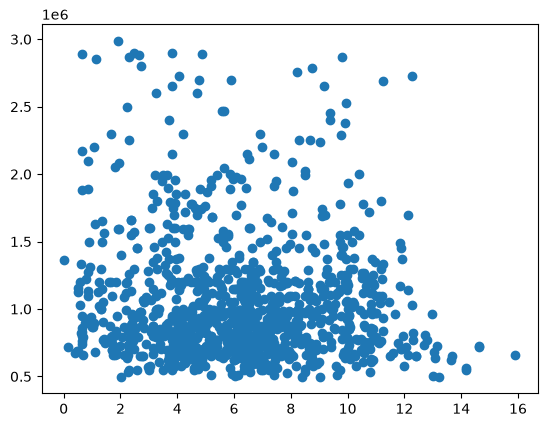

In [20]:
#price vs centreDistance
plt.scatter(df["centreDistance"],df["price"])
#it conforms that there is no strong correlation between those 2 variables

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
 [Text(0, 0, 'Wesoła'),
  Text(1, 0, 'Bielany'),
  Text(2, 0, 'Rembertów'),
  Text(3, 0, 'Wawer'),
  Text(4, 0, 'Białołęka'),
  Text(5, 0, 'Targówek'),
  Text(6, 0, 'Ursus'),
  Text(7, 0, 'Włochy'),
  Text(8, 0, 'Praga-Północ'),
  Text(9, 0, 'Ochota'),
  Text(10, 0, 'Praga-Południe'),
  Text(11, 0, 'Bemowo'),
  Text(12, 0, 'Wola'),
  Text(13, 0, 'Mokotów'),
  Text(14, 0, 'Ursynów'),
  Text(15, 0, 'Śródmieście'),
  Text(16, 0, 'Żoliborz'),
  Text(17, 0, 'Wilanów')])

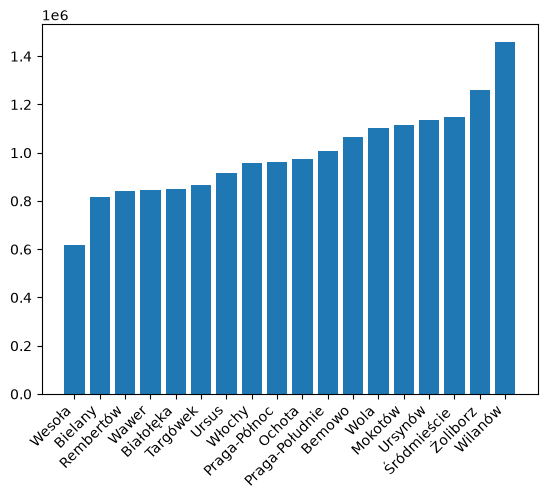

In [26]:
#mean price in each district
avg=df.groupby("district")["price"].mean().sort_values()
plt.bar(avg.index, avg.values)
plt.xticks(rotation=45, ha="right")
#it shows us that the biggest mean value are in Wilanów, but the smallest mean is Wesoła